# Option pricing with time-varying volatility

**Part 1 of 2.** European and American options, priced on the SOR solver from the
C++ PDE project, with volatility that changes through time.

The argument of the notebook, in order:

1. Take a real SPX option chain and read the forward, the discount factor and the
   volatility term structure straight out of it
2. Change one thing in Black-Scholes: volatility becomes a function of time
3. Show the closed form still works in that case, so there is something exact to
   check against
4. Build the PDE solver and check it converges to that exact answer
5. Price an American option, where no closed form exists and the PDE genuinely wins

Part 2 does Asian options and the Vecer reduction.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from math import log, sqrt, exp, erf

import spx_chain

plt.rcParams.update({'figure.figsize': (11, 5), 'axes.grid': True, 'grid.alpha': 0.3,
                     'font.size': 10, 'axes.spines.top': False, 'axes.spines.right': False})

## 1. What the market is telling us

An option chain is a big table of prices. Three things have to come out of it before
anything can be priced:

- **the forward** - what the market thinks the index will be worth at expiry
- **the discount factor** - how much a payment at expiry is worth today
- **the volatility** - how much movement the market is charging for

The first two come from **put-call parity**, which is not a model. It is an accounting
identity: owning a call and selling a put is the same as agreeing now to buy the index
at expiry. So

    call - put = discounted (forward - strike)

Plot the left side against strike and it is a straight line. The slope gives the
discount factor and the crossing point gives the forward.

In [2]:
rows = spx_chain.load('data/spx_chain_2023-01-04.csv')
good = spx_chain.usable(rows)

print(f"{len(rows)} rows, {len(good)} usable")
print(f"quote date {rows[0]['quote_date']}, index level {rows[0]['underlying']}")

term = spx_chain.term_structure(good)
term = [t for t in term if not np.isnan(t['atm_vol'])]
print(f"{len(term)} expiries with a fit, from {term[0]['dte']:.0f} to {term[-1]['dte']:.0f} days")

5024 rows, 4495 usable
quote date 2023-01-04, index level 3853.39
46 expiries with a fit, from 1 to 716 days


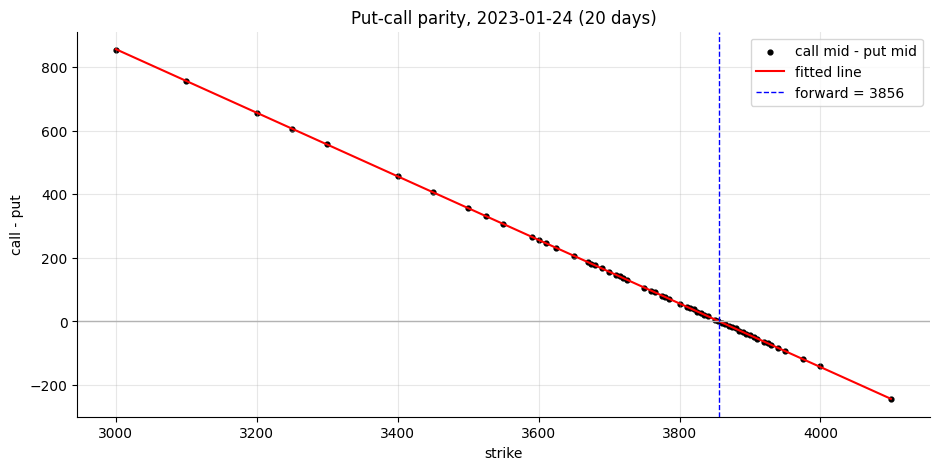

In [3]:
#the parity line for one expiry, drawn rather than asserted
group = [r for r in good if r['expiry'] == term[12]['expiry']]
strikes = np.array([r['strike'] for r in group])
diffs = np.array([0.5*(r['call_bid']+r['call_ask']) - 0.5*(r['put_bid']+r['put_ask'])
                  for r in group])
ok = ~np.isnan(diffs)

forward, discount = spx_chain.forward_from_parity(group)

fig, ax = plt.subplots()
ax.scatter(strikes[ok], diffs[ok], s=12, color='k', label='call mid - put mid')
ax.plot(strikes[ok], discount*(forward - strikes[ok]), 'r-', lw=1.5, label='fitted line')
ax.axhline(0, color='0.7', lw=1)
ax.axvline(forward, color='b', ls='--', lw=1, label=f'forward = {forward:.0f}')
ax.set_xlabel('strike')
ax.set_ylabel('call - put')
ax.set_title(f"Put-call parity, {term[12]['expiry']} ({term[12]['dte']:.0f} days)")
ax.legend()
plt.show()

### The check that validates everything

Nothing in the code knows what interest rates were on 4 January 2023. But the discount
factor at each expiry is `exp(-r x T)`, so the rate can be read back out.

If the number that comes out matches what rates actually were, then the parsing, the
filtering and the parity fit are all correct at once.

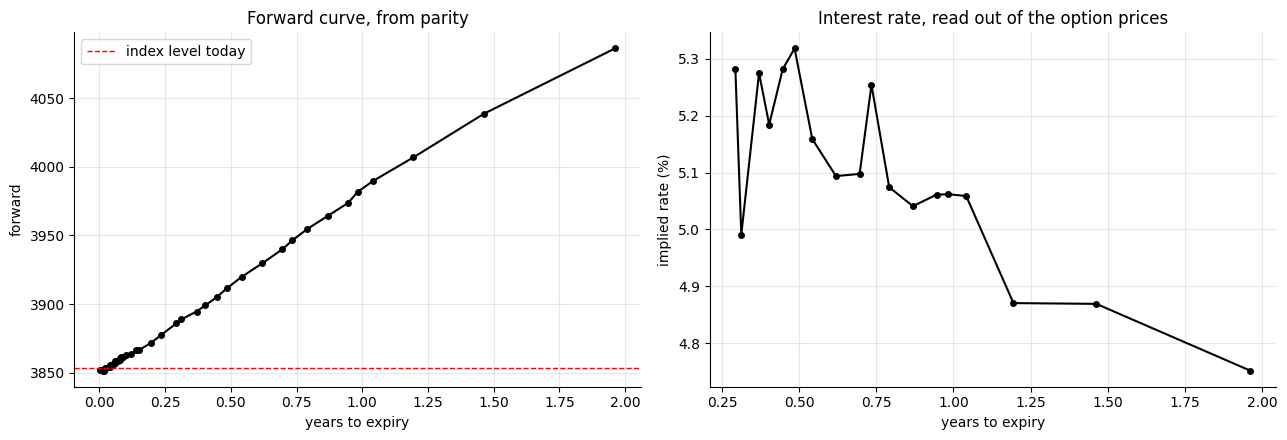

implied rate at the long end: 4.75% a year
US rates in January 2023 were around 4.5-5%, so the pipeline is doing its job


In [4]:
years = np.array([t['years'] for t in term])
discounts = np.array([t['discount'] for t in term])
forwards = np.array([t['forward'] for t in term])
atm_vols = np.array([t['atm_vol'] for t in term])

#implied rate at each expiry
long_end = years > 0.25                              # short expiries are too noisy for this
implied_rates = -np.log(discounts[long_end])/years[long_end]

fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))
axes[0].plot(years, forwards, 'o-', color='k', ms=4)
axes[0].axhline(rows[0]['underlying'], color='r', ls='--', lw=1, label='index level today')
axes[0].set_xlabel('years to expiry'); axes[0].set_ylabel('forward')
axes[0].set_title('Forward curve, from parity'); axes[0].legend()

axes[1].plot(years[long_end], 100*implied_rates, 'o-', color='k', ms=4)
axes[1].set_xlabel('years to expiry'); axes[1].set_ylabel('implied rate (%)')
axes[1].set_title('Interest rate, read out of the option prices')
plt.tight_layout()
plt.show()

print(f"implied rate at the long end: {100*implied_rates[-1]:.2f}% a year")
print("US rates in January 2023 were around 4.5-5%, so the pipeline is doing its job")

## 2. The volatility term structure

One number per expiry: the implied volatility of the option closest to the forward.

Stacked up, these are **sigma(t)** - the only thing being changed relative to textbook
Black-Scholes.

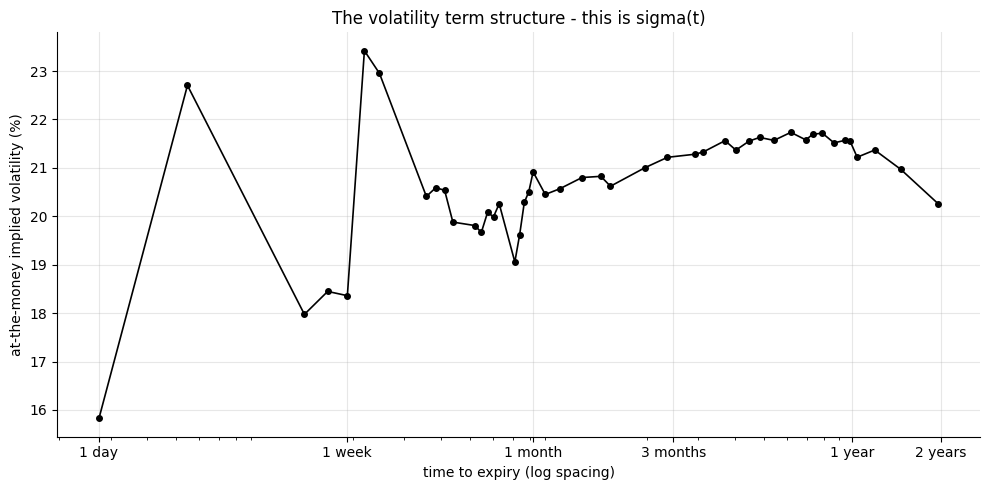

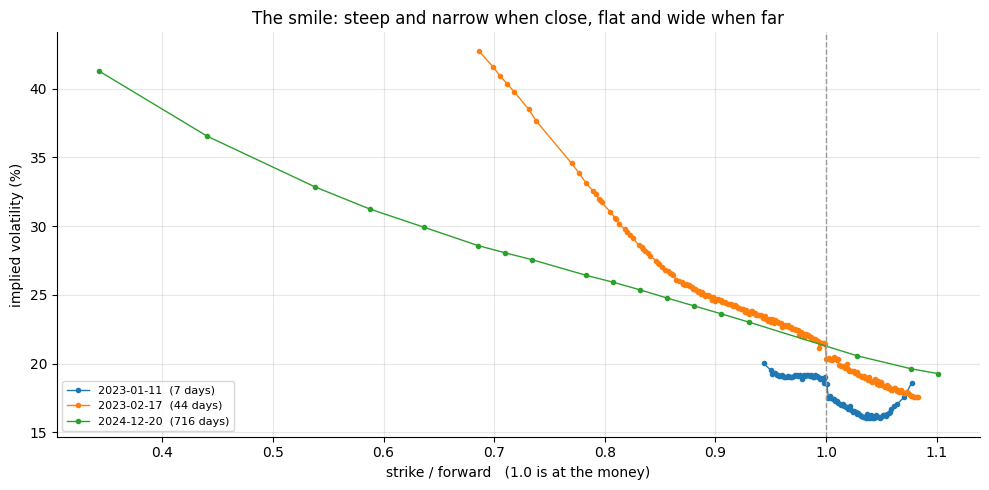

In [5]:
spx_chain.plot_term_structure(term)
plt.show()

spx_chain.plot_smiles(good, [term[4]['expiry'], term[len(term)//2]['expiry'], term[-1]['expiry']])
plt.show()

### From term volatility to forward volatility

Careful here, because there are two different quantities and mixing them up is the usual
mistake.

- The **term volatility** at one year is an average over the whole year.
- The **forward volatility** between month six and month seven is the volatility *during
  that month*.

The pricer needs the second one. Getting it is easier than it sounds, because variance
adds up over time. Define total variance to expiry:

    w(T) = sigma_term(T)^2 x T

Total variance is the thing that accumulates, so the variance *during* an interval is
just the difference, and the forward volatility is

    sigma_fwd = sqrt( (w(T2) - w(T1)) / (T2 - T1) )

**One honest problem shows up immediately.** Total variance must increase with maturity -
otherwise there is a free lunch, because you could buy the longer option and sell the
shorter one and be paid to take less risk. In the real quotes it does not always
increase. That is a small calendar arbitrage in the market's own mid prices, usually from
comparing a weekly against a monthly expiry, and it has to be cleaned up before the
square root is taken.

expiries where total variance failed to increase: 1 of 45


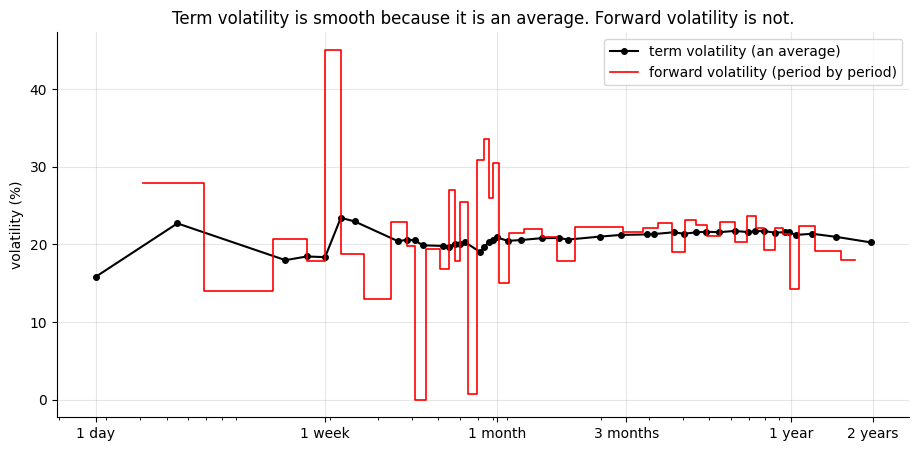

In [6]:
total_variance = atm_vols**2 * years

#check the no-free-lunch condition before relying on it
violations = np.sum(np.diff(total_variance) <= 0)
print(f"expiries where total variance failed to increase: {violations} of {len(total_variance)-1}")

#force it to increase, keeping everything else as it is
w_clean = np.maximum.accumulate(total_variance)

forward_var = np.diff(w_clean)/np.diff(years)
forward_vol = np.sqrt(np.maximum(forward_var, 1e-8))
mid_years = 0.5*(years[1:] + years[:-1])

fig, ax = plt.subplots()
ax.plot(years, 100*atm_vols, 'o-', color='k', ms=4, label='term volatility (an average)')
ax.step(mid_years, 100*forward_vol, where='mid', color='r', lw=1.2,
        label='forward volatility (period by period)')
ax.set_xscale('log')
ax.set_xticks([1/365, 7/365, 30/365, 90/365, 1, 2])
ax.set_xticklabels(['1 day', '1 week', '1 month', '3 months', '1 year', '2 years'])
ax.set_ylabel('volatility (%)')
ax.set_title('Term volatility is smooth because it is an average. Forward volatility is not.')
ax.legend()
plt.show()

In [7]:
#-------- sigma(t) as a function the pricer can call ------------------------
#-----------------------------------------------------------------------------
# Piecewise constant between expiries, flat outside the range. Deliberately
# simple - fitting a smooth curve would hide the jumps, and the jumps are real.
def make_sigma(mid_years, forward_vol):
    def sigma(t):
        return float(np.interp(t, mid_years, forward_vol,
                               left=forward_vol[0], right=forward_vol[-1]))
    return sigma

sigma_market = make_sigma(mid_years, forward_vol)

for t in [0.05, 0.25, 0.5, 1.0, 1.9]:
    print(f"sigma at {t:4.2f} years: {100*sigma_market(t):.1f}%")

sigma at 0.05 years: 18.4%
sigma at 0.25 years: 21.8%
sigma at 0.50 years: 21.5%
sigma at 1.00 years: 16.1%
sigma at 1.90 years: 18.0%


## 3. Black-Scholes still has an exact answer

The useful fact about letting volatility depend on time alone:

**Only the total variance matters, not how it was distributed.** A year at 20%
and a year that spends six months at 10% and six months at roughly 27% give the same
option price, because the option only cares about the accumulated uncertainty at expiry.

So the closed form survives untouched. Wherever the textbook formula has `sigma^2 x T`,
substitute

    integral of sigma(t)^2 dt from 0 to T

and everything else is identical. That is worth stressing, because it means the European
case has an exact answer to test the solver against.

In [8]:
#-------- The normal distribution function -----------------------------------
#-----------------------------------------------------------------------------
# The probability a standard normal lands below x. Written out via erf rather
# than imported, since it is one line and it is the only special function here.
def normal_cdf(x):
    return 0.5*(1.0 + erf(x/sqrt(2.0)))


#-------- Total variance by integrating sigma(t)^2 ---------------------------
#-----------------------------------------------------------------------------
def total_variance_to(T, sigma_fn, n_steps=2000):
    t = np.linspace(0, T, n_steps)
    dt = t[1] - t[0]
    midpoints = 0.5*(t[1:] + t[:-1])                    # sample in the middle of each slice
    return float(np.sum([sigma_fn(ti)**2 for ti in midpoints])*dt)


#-------- Black-Scholes in forward form --------------------------------------
#-----------------------------------------------------------------------------
# Written in terms of the forward and the discount factor rather than spot,
# rate and dividend yield - because the forward and the discount are what parity
# gave us directly, and using them avoids inventing a dividend assumption.
def bs_call(forward, strike, total_var, discount):
    if total_var <= 0:
        return discount*max(forward - strike, 0.0)
    v = sqrt(total_var)
    d1 = (log(forward/strike) + 0.5*total_var)/v
    d2 = d1 - v
    return discount*(forward*normal_cdf(d1) - strike*normal_cdf(d2))


def bs_put(forward, strike, total_var, discount):
    #from parity, so the two can never disagree
    return bs_call(forward, strike, total_var, discount) - discount*(forward - strike)


#a quick check that flat volatility reproduces the textbook number
print("flat 20% vol, 1 year, F=K=100, no discounting:")
print(f"  {bs_call(100, 100, 0.2**2*1.0, 1.0):.4f}   (textbook value is 7.9656)")

flat 20% vol, 1 year, F=K=100, no discounting:
  7.9656   (textbook value is 7.9656)


## 4. The PDE solver

Everything so far has an exact answer. This section builds the machine that does not
need one.

**The equation.** In log-price coordinates `x = log(S)`, the Black-Scholes equation is

    dV/dt + 0.5 sigma(t)^2 Vxx + (r - q - 0.5 sigma(t)^2) Vx - rV = 0

Log coordinates are worth the change of variable: the coefficients stop depending on the
price level, so the grid can be evenly spaced.

**The scheme.** Step backwards from expiry. At each step, half the spatial derivative is
evaluated at the old time and half at the new one - the Crank-Nicolson scheme, which is
second-order accurate in both space and time.

**The two details that separate a working solver from a broken one:**

1. **Rannacher startup.** The payoff has a sharp kink at the strike. Crank-Nicolson
   handles smooth things beautifully and rings against kinks, producing oscillations
   near the strike that poison the Greeks. The fix is to take the first two steps fully
   implicit, which damps the kink, then switch to Crank-Nicolson. Two lines.

2. **The linear solve.** Each step needs a tridiagonal system solved, and that is exactly
   what the SOR routine from the C++ project does. It is reused here unchanged in
   substance - guess, sweep, relax, repeat until nothing moves.

In [9]:
#-------- SOR : the solver from the C++ PDE project --------------------------
#-----------------------------------------------------------------------------
# Successive over-relaxation. Sweep through the unknowns, and at each one compute
# what the equation says it should be given its neighbours' current values. The
# relaxation factor omega decides how far to move toward that value:
#
#   omega = 1     plain Gauss-Seidel, move exactly there
#   omega > 1     overshoot deliberately, which converges faster
#   omega >= 2    unstable, the iteration diverges
#
# Here the matrix is tridiagonal, so each unknown has exactly two neighbours.
def sor_solve(lower, diag, upper, rhs, guess, omega=1.5, tol=1e-10, max_iterations=20000):
    x = guess.copy()
    n = len(rhs)

    for iteration in range(max_iterations):
        x_previous = x.copy()

        for i in range(n):
            residual = rhs[i]
            if i > 0:
                residual -= lower[i]*x[i-1]             # the neighbour below
            if i < n-1:
                residual -= upper[i]*x[i+1]             # the neighbour above
            x[i] = (1 - omega)*x[i] + omega*residual/diag[i]

        if np.max(np.abs(x - x_previous)) < tol:        # nothing moved, we are done
            return x, iteration + 1

    return x, max_iterations


#-------- Projected SOR : the same thing, for American options ---------------
#-----------------------------------------------------------------------------
# One extra line, and it is the whole of the American option.
#
# An American option can be exercised at any time, so its value can never fall
# below what exercising right now would pay. After computing each new value,
# push it back up to the payoff if it has dropped below. The boundary between
# "exercise now" and "keep waiting" comes out of this automatically - it is
# never specified, which is what makes it a free boundary problem.
def projected_sor(lower, diag, upper, rhs, guess, payoff, omega=1.2,
                  tol=1e-10, max_iterations=20000):
    x = guess.copy()
    n = len(rhs)

    for iteration in range(max_iterations):
        x_previous = x.copy()

        for i in range(n):
            residual = rhs[i]
            if i > 0:
                residual -= lower[i]*x[i-1]
            if i < n-1:
                residual -= upper[i]*x[i+1]
            value = (1 - omega)*x[i] + omega*residual/diag[i]
            x[i] = max(value, payoff[i])                # <- the projection

        if np.max(np.abs(x - x_previous)) < tol:
            return x, iteration + 1

    return x, max_iterations

In [10]:
#-------- The pricer ---------------------------------------------------------
#-----------------------------------------------------------------------------
# Backward through time from expiry to today. At each step:
#   build the tridiagonal system for this time step
#   solve it with SOR (or projected SOR for American)
#   impose the boundary values at the two ends of the grid
#
# The grid runs five standard deviations either side of the starting price, which
# is far enough that the boundary treatment does not affect the answer in the middle.
def price_pde(spot, strike, expiry, sigma_fn, rate, dividend,
              n_space=200, n_time=200, omega=1.5, option='call',
              american=False, rannacher=True, track_boundary=False):

    #grid in log price, evenly spaced
    reference_vol = sigma_fn(expiry/2)
    half_width = 5.0*reference_vol*sqrt(expiry)
    x = np.linspace(log(spot) - half_width, log(spot) + half_width, n_space + 1)
    dx = x[1] - x[0]
    S = np.exp(x)

    payoff = np.maximum(S - strike, 0.0) if option == 'call' else np.maximum(strike - S, 0.0)
    V = payoff.copy()                                   # value at expiry is the payoff
    dt = expiry/n_time

    iterations_used = 0
    boundary = []

    for step in range(n_time):
        time_now = expiry - step*dt
        sigma = sigma_fn(time_now - 0.5*dt)             # volatility over this step

        #fully implicit for the first two steps (Rannacher), Crank-Nicolson after
        implicit_weight = 1.0 if (rannacher and step < 2) else 0.5
        explicit_weight = 1.0 - implicit_weight

        #the three coefficients of the discretised operator
        a = 0.5*sigma*sigma/(dx*dx)
        b = (rate - dividend - 0.5*sigma*sigma)/(2*dx)
        L = a - b                                       # multiplies V[i-1]
        D = -2*a - rate                                 # multiplies V[i]
        U = a + b                                       # multiplies V[i+1]

        #right hand side: the part evaluated at the old time level
        operator_V = L*V[:-2] + D*V[1:-1] + U*V[2:]
        rhs = V[1:-1] + explicit_weight*dt*operator_V

        diag = (1 - implicit_weight*dt*D)*np.ones(n_space - 1)
        lower = -implicit_weight*dt*L*np.ones(n_space - 1)
        upper = -implicit_weight*dt*U*np.ones(n_space - 1)

        #boundaries: deep out of the money the option is worthless, deep in the money
        #it behaves like the forward minus the discounted strike
        tau = (step + 1)*dt                             # time from expiry back to here
        if option == 'call':
            value_low = 0.0
            value_high = S[-1]*exp(-dividend*tau) - strike*exp(-rate*tau)
        else:
            value_low = strike*exp(-rate*tau) - S[0]*exp(-dividend*tau)
            value_high = 0.0
        if american:
            value_low = max(value_low, payoff[0])
            value_high = max(value_high, payoff[-1])

        rhs[0] += implicit_weight*dt*L*value_low
        rhs[-1] += implicit_weight*dt*U*value_high

        if american:
            solution, iterations = projected_sor(lower, diag, upper, rhs,
                                                 V[1:-1].copy(), payoff[1:-1], omega=omega)
        else:
            solution, iterations = sor_solve(lower, diag, upper, rhs,
                                             V[1:-1].copy(), omega=omega)
        iterations_used += iterations

        V[1:-1] = solution
        V[0] = value_low
        V[-1] = value_high

        #where does holding stop being worth more than exercising?
        if track_boundary and american:
            exercising = np.where(V <= payoff + 1e-8)[0]
            if option == 'put' and len(exercising) > 0:
                boundary.append((expiry - tau, S[exercising[-1]]))

    price = float(np.interp(log(spot), x, V))
    return {'price': price, 'iterations': iterations_used,
            'grid': S, 'values': V, 'boundary': boundary}

## 5. Does it work?

Two tests. Flat volatility against the textbook formula, then time-varying volatility
against the same formula fed the integrated variance.

The second test is the one that matters: it confirms that the solver is handling the
changing coefficient correctly and not quietly using an average.

In [11]:
S0, K, T = 100.0, 100.0, 1.0
r, q = 0.05, 0.02
forward = S0*exp((r - q)*T)
discount = exp(-r*T)

#test 1 - flat volatility
flat = lambda t: 0.20
exact_flat = bs_call(forward, K, total_variance_to(T, flat), discount)
pde_flat = price_pde(S0, K, T, flat, r, q, n_space=200, n_time=200)['price']

print("flat volatility, 20%")
print(f"  closed form : {exact_flat:.5f}")
print(f"  PDE         : {pde_flat:.5f}     error {pde_flat-exact_flat:+.5f}")

#test 2 - volatility that changes a lot through the year
ramp = lambda t: 0.10 + 0.25*t
exact_ramp = bs_call(forward, K, total_variance_to(T, ramp), discount)
pde_ramp = price_pde(S0, K, T, ramp, r, q, n_space=200, n_time=200)['price']

print("\nvolatility rising from 10% to 35% through the year")
print(f"  closed form : {exact_ramp:.5f}")
print(f"  PDE         : {pde_ramp:.5f}     error {pde_ramp-exact_ramp:+.5f}")

flat volatility, 20%
  closed form : 9.22701
  PDE         : 9.22466     error -0.00235



volatility rising from 10% to 35% through the year
  closed form : 10.60352
  PDE         : 10.60077     error -0.00275


### Convergence: is it second order?

A claim like "second-order accurate" is testable. Halve the grid spacing and the error
should fall by a factor of four.

On a log-log plot of error against grid size, that is a straight line of slope -2. Fit
the slope and read it off rather than asserting it.

  n =   25   error 0.201646
  n =   50   error 0.037879


  n =  100   error 0.009415


  n =  200   error 0.002350


  n =  400   error 0.000587


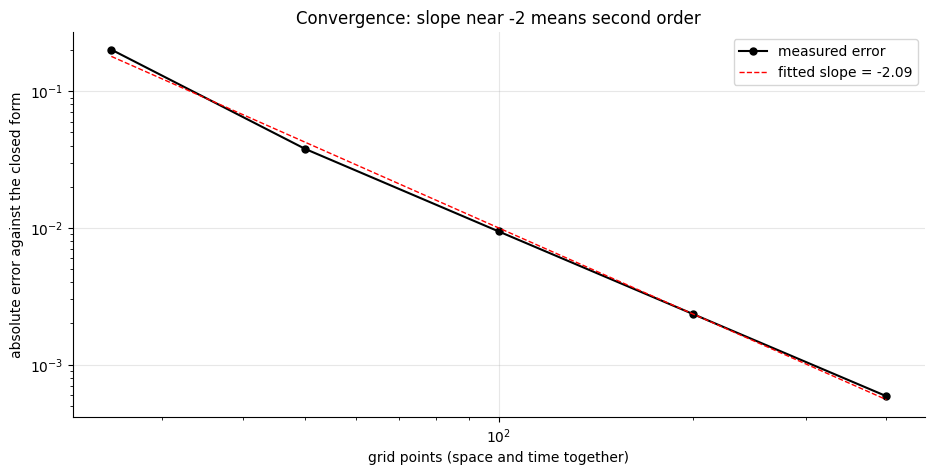


fitted convergence order: 2.09   (theory says 2)


In [12]:
sizes = [25, 50, 100, 200, 400]
errors = []
for n in sizes:
    p = price_pde(S0, K, T, flat, r, q, n_space=n, n_time=n)['price']
    errors.append(abs(p - exact_flat))
    print(f"  n = {n:4d}   error {errors[-1]:.6f}")

errors = np.array(errors, dtype=float)
slope, intercept = np.polyfit(np.log(sizes), np.log(errors), 1)

fig, ax = plt.subplots()
ax.loglog(sizes, errors, 'o-', color='k', ms=5, label='measured error')
ax.loglog(sizes, np.exp(intercept)*np.array(sizes, dtype=float)**slope, 'r--', lw=1,
          label=f'fitted slope = {slope:.2f}')
ax.set_xlabel('grid points (space and time together)')
ax.set_ylabel('absolute error against the closed form')
ax.set_title('Convergence: slope near -2 means second order')
ax.legend()
plt.show()

print(f"\nfitted convergence order: {-slope:.2f}   (theory says 2)")

### The relaxation parameter

The one free knob in SOR. Too low and it crawls, too high and it diverges, and the best
value sits somewhere in between and depends on the problem.

This is a figure worth having because it shows a numerical method's real behaviour
rather than its advertised behaviour.

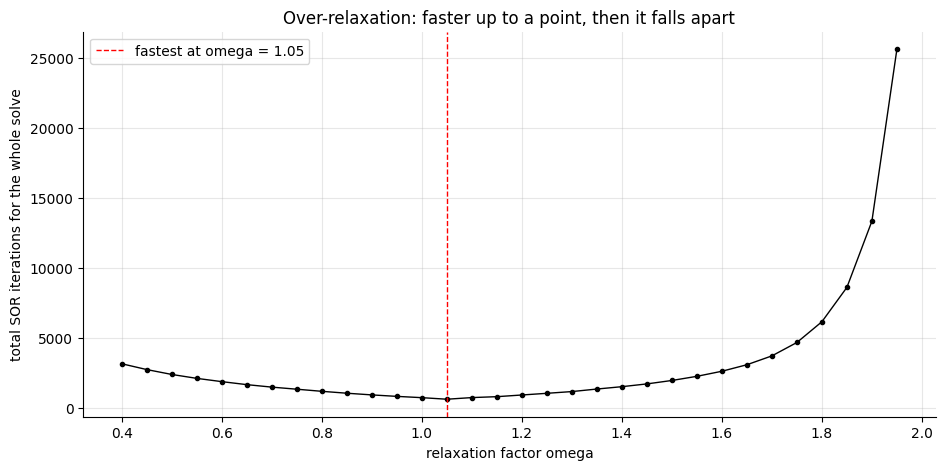

In [13]:
omegas = np.arange(0.4, 1.96, 0.05)
counts = []
for w in omegas:
    result = price_pde(S0, K, T, flat, r, q, n_space=60, n_time=60, omega=w)
    counts.append(result['iterations'])

best = omegas[int(np.argmin(counts))]

fig, ax = plt.subplots()
ax.plot(omegas, counts, 'o-', color='k', ms=3, lw=1)
ax.axvline(best, color='r', ls='--', lw=1, label=f'fastest at omega = {best:.2f}')
ax.set_xlabel('relaxation factor omega')
ax.set_ylabel('total SOR iterations for the whole solve')
ax.set_title('Over-relaxation: faster up to a point, then it falls apart')
ax.legend()
plt.show()

## 6. Pricing with the market's own volatility curve

Everything above used made-up volatility. Now use `sigma_market`, the forward volatility
curve extracted from the SPX chain in section 2, and price an option at a maturity the
market actually quotes.

The comparison is against the market's own mid price. They will not match exactly, and
the reasons are worth listing rather than hiding: the at-the-money volatility ignores
the smile, the chosen strike is not exactly at the forward, and the quotes are
end-of-day mid prices rather than anything tradeable.

In [14]:
#pick an expiry around six months out
target = min(term, key=lambda t: abs(t['years'] - 0.5))
group = [r for r in good if r['expiry'] == target['expiry']]

#the strike closest to the forward
closest = min(group, key=lambda r: abs(r['strike'] - target['forward']))
market_call = 0.5*(closest['call_bid'] + closest['call_ask'])

T_mkt = target['years']
rate = -log(target['discount'])/T_mkt
dividend = rate - log(target['forward']/rows[0]['underlying'])/T_mkt

model_closed = bs_call(target['forward'], closest['strike'],
                       total_variance_to(T_mkt, sigma_market), target['discount'])
model_pde = price_pde(rows[0]['underlying'], closest['strike'], T_mkt,
                      sigma_market, rate, dividend, n_space=300, n_time=300)['price']

print(f"expiry {target['expiry']}  ({target['dte']:.0f} days)")
print(f"forward {target['forward']:.1f}, strike {closest['strike']:.0f}")
print(f"implied rate {100*rate:.2f}%, implied dividend yield {100*dividend:.2f}%")
print()
print(f"  market mid  : {market_call:.2f}")
print(f"  closed form : {model_closed:.2f}")
print(f"  PDE         : {model_pde:.2f}")
print(f"\nPDE against closed form: {model_pde-model_closed:+.3f}")

expiry 2023-06-30  (177 days)
forward 3911.5, strike 3900
implied rate 5.32%, implied dividend yield 2.23%

  market mid  : 238.05
  closed form : 233.50
  PDE         : 233.47

PDE against closed form: -0.027


## 7. American options, where the PDE earns its place

An American option can be exercised at any moment, so at every price and every date there
is a decision: take the payoff now, or keep waiting.

The line separating those two regions is the **early exercise boundary**, and it is not
known in advance - it has to be solved for alongside the price. That is why this is
called a free boundary problem, and it is why there is no formula.

The projection inside `projected_sor` is the entire implementation. Value falls below the
immediate payoff, push it back up, and the boundary appears by itself.

**Check it against something independent.** A binomial tree is a completely different
numerical method - a discrete lattice of up and down moves rather than a differential
equation - so if the two agree, both are probably right.

In [15]:
#-------- Binomial tree, as an independent check -----------------------------
#-----------------------------------------------------------------------------
# Nothing to do with PDEs. The price moves up or down by a fixed factor each
# step; work backwards taking the better of holding and exercising.
def binomial_american_put(spot, strike, expiry, sigma, rate, dividend, n_steps=2000):
    dt = expiry/n_steps
    up = exp(sigma*sqrt(dt))
    down = 1.0/up
    p_up = (exp((rate - dividend)*dt) - down)/(up - down)     # risk neutral probability
    discount_step = exp(-rate*dt)

    S = spot*up**np.arange(n_steps, -n_steps-1, -2.0)
    V = np.maximum(strike - S, 0.0)

    for i in range(n_steps-1, -1, -1):
        S = spot*up**np.arange(i, -i-1, -2.0)
        V = discount_step*(p_up*V[:-1] + (1 - p_up)*V[1:])
        V = np.maximum(V, strike - S)                          # exercise if better
    return float(V[0])


sigma_flat = 0.20
european_put = bs_put(S0*exp((r-0.0)*T), K, sigma_flat**2*T, exp(-r*T))
tree = binomial_american_put(S0, K, T, sigma_flat, r, 0.0)
pde = price_pde(S0, K, T, lambda t: sigma_flat, r, 0.0,
                n_space=200, n_time=200, omega=1.2, option='put',
                american=True, track_boundary=True)

print(f"European put, closed form      : {european_put:.4f}")
print(f"American put, binomial tree     : {tree:.4f}")
print(f"American put, projected SOR     : {pde['price']:.4f}     difference {pde['price']-tree:+.4f}")
print(f"\nearly exercise is worth        : {tree - european_put:.4f}")

European put, closed form      : 5.5735
American put, binomial tree     : 6.0900
American put, projected SOR     : 6.0871     difference -0.0029

early exercise is worth        : 0.5165


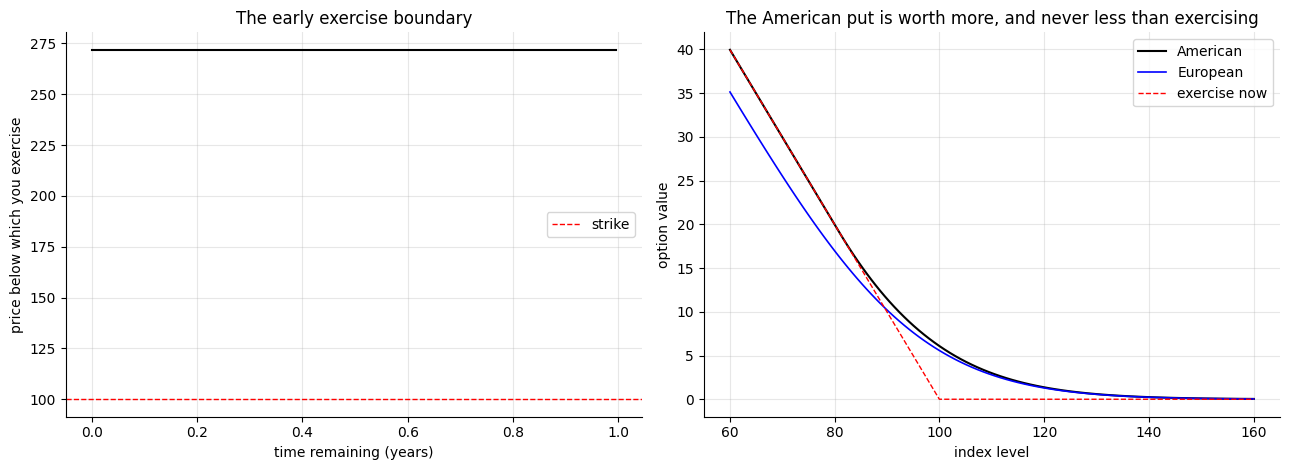

In [16]:
#the boundary that came out of the projection, never specified anywhere
boundary = np.array(pde['boundary'])

fig, axes = plt.subplots(1, 2, figsize=(13, 4.8))

axes[0].plot(boundary[:, 0], boundary[:, 1], 'k-', lw=1.5)
axes[0].axhline(K, color='r', ls='--', lw=1, label='strike')
axes[0].set_xlabel('time remaining (years)')
axes[0].set_ylabel('price below which you exercise')
axes[0].set_title('The early exercise boundary')
axes[0].legend()

#value against price, American above European by the early exercise premium
S_grid = pde['grid']
window = (S_grid > 60) & (S_grid < 160)
european_curve = [bs_put(s*exp(r*T), K, sigma_flat**2*T, exp(-r*T)) for s in S_grid[window]]

axes[1].plot(S_grid[window], pde['values'][window], 'k-', lw=1.5, label='American')
axes[1].plot(S_grid[window], european_curve, 'b-', lw=1.2, label='European')
axes[1].plot(S_grid[window], np.maximum(K - S_grid[window], 0), 'r--', lw=1,
             label='exercise now')
axes[1].set_xlabel('index level')
axes[1].set_ylabel('option value')
axes[1].set_title('The American put is worth more, and never less than exercising')
axes[1].legend()
plt.tight_layout()
plt.show()

## What this notebook establishes

- The forward, the discount factor and the volatility curve all come out of the option
  chain itself. The implied interest rate matching real January 2023 rates is the
  evidence that the extraction is right.
- Letting volatility depend on time changes almost nothing mathematically - only the
  integral of `sigma(t)^2` matters - but it changes the solver, because the coefficients
  now move at every step.
- The solver converges at second order, measured rather than claimed.
- Crank-Nicolson needs the Rannacher startup, and the relaxation factor has a real
  optimum that can be found by sweeping it.
- Projected SOR prices an American option to within about half a cent of a binomial tree
  built on completely different principles, and produces the early exercise boundary as
  a by-product.

**Part 2:** Asian options. The payoff depends on the average price, so the state is two
dimensional - price and running average - until a change of numeraire collapses it back
to one, at which point this same solver prices it.